# Automatic classification of English poetry by meter


## 1. Library import

In [1]:
import pandas as pd
import copy
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import MinMaxScaler


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 2. Data import and manipulation

In [3]:
df = pd.read_csv("forbetterverse.csv", sep=";")

In [4]:
# keeping rows for which there is relevant data
df = df.dropna(subset=["met", "meter_quality", "feet_number"])
df = df.reset_index(drop=True)
# cleaning the column names
df["feet_number"] = df["feet_number"].replace("pentamer", "pentameter")

In [5]:
# transforming raw stress annotations ("+" for stressed, "-" for unstressed syllable) to binary sequences
def parse_real(x):
    x = x.split("|")[0] # sometimes two intepretations are given separated by "|" : we keep the first one
    """
    '--+--+' → [0,0,1,0,0,1]
    """
    return [1 if c == '+' else 0 for c in str(x) if c in ['+','-']]

df["sequence"] = df["real"].apply(parse_real)
df[["real", "sequence"]].head()

,real,sequence
0,+--+--+++,"[1, 0, 0, 1, 0, 0, 1, 1, 1]"
1,+--+--+-,"[1, 0, 0, 1, 0, 0, 1, 0]"
2,+-+--+--+,"[1, 0, 1, 0, 0, 1, 0, 0, 1]"
3,+--+--+--+,"[1, 0, 0, 1, 0, 0, 1, 0, 0, 1]"
4,-+--+-+--+,"[0, 1, 0, 0, 1, 0, 1, 0, 0, 1]"


In [6]:
# putting foot type and number of feet per line to create metre classes
df["label_full"] = df["meter_quality"].str.lower() + "_" + df["feet_number"].str.lower()
print(df["label_full"].value_counts())

label_full
iambic_pentameter       732
iambic_tetrameter       345
iambic_trimeter         150
anapestic_tetrameter     35
anapestic_trimeter       26
trochaic_tetrameter      26
iambic_hexameter         22
anapestic_pentameter     17
dactylic_tetrameter      13
anapestic_hexameter       4
iambic_monometer          4
trochaic_trimeter         3
anapestic_monometer       2
spondaic_tetrameter       1
Name: count, dtype: int64


In [7]:
counts = df["label_full"].value_counts()

# Dropping too unfrequent classes
valid_labels = counts[counts >= 10].index
df = df[df["label_full"].isin(valid_labels)].reset_index(drop=True)

# Converting sting classes into numeric values
label_to_id = {"iambic_pentameter" : 0, "iambic_tetrameter" : 1, "iambic_trimeter": 2,"anapestic_tetrameter": 3, "anapestic_trimeter" : 4, "trochaic_tetrameter" : 5,  "iambic_hexameter" : 6, "anapestic_pentameter" : 7, "dactylic_tetrameter" : 8 }

In [8]:
df

,line,met,real,feet,feet_number,meter_quality,line_n,title,author,meter_nuber,sequence,label_full
0,"What was he doing, the great god Pan,",--+--+--+--+,+--+--+++,"What was |he do|ing, the great |god Pan,",tetrameter,anapestic,1,A Musical Instrument(1860),Elizabeth Barrett Browning,NaN,"[1, 0, 0, 1, 0, 0, 1, 1, 1]",anapestic_tetrameter
1,Down in the reeds by the river?,--+--+--+,+--+--+-,Down in |the reeds |by the river?,trimeter,anapestic,2,A Musical Instrument(1860),Elizabeth Barrett Browning,NaN,"[1, 0, 0, 1, 0, 0, 1, 0]",anapestic_trimeter
2,"Spreading ruin and scattering ban,",--+--+--+--+,+-+--+--+,"Spreading |ruin |and scat|tering ban,",tetrameter,anapestic,3,A Musical Instrument(1860),Elizabeth Barrett Browning,NaN,"[1, 0, 1, 0, 0, 1, 0, 0, 1]",anapestic_tetrameter
3,"Splashing and paddling with hoofs of a goat,",--+--+--+--+,+--+--+--+,"Splashing |and pad|dling with hoofs |of a goat,",tetrameter,anapestic,4,A Musical Instrument(1860),Elizabeth Barrett Browning,NaN,"[1, 0, 0, 1, 0, 0, 1, 0, 0, 1]",anapestic_tetrameter
4,And breaking the golden lilies afloat,--+--+--+--+,-+--+-+--+,And break|ing the gold|en lil|ies afloat,tetrameter,anapestic,5,A Musical Instrument(1860),Elizabeth Barrett Browning,NaN,"[0, 1, 0, 0, 1, 0, 1, 0, 0, 1]",anapestic_tetrameter
...,...,...,...,...,...,...,...,...,...,...,...,...
1361,"And get knocked on the head for his labours,",--+--+--+,--+--+--+-,"And get knocked |on the head |for his labours,",trimeter,anapestic,4,When a Man Hath No Freedom(1820),"George Gordon, Lord Byron",NaN,"[0, 0, 1, 0, 0, 1, 0, 0, 1, 0]",anapestic_trimeter
1362,"To do good to mankind is the chivalrous plan,",--+--+--+--+,--+--+--+--+,"To do good |to mankind |is the chiv|alrous plan,",tetrameter,anapestic,5,When a Man Hath No Freedom(1820),"George Gordon, Lord Byron",NaN,"[0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1]",anapestic_tetrameter
1363,And is always as nobly requited;,--+--+--+,--+--+--+-,And is al|ways as no|bly requited;,trimeter,anapestic,6,When a Man Hath No Freedom(1820),"George Gordon, Lord Byron",NaN,"[0, 0, 1, 0, 0, 1, 0, 0, 1, 0]",anapestic_trimeter
1364,"Then battle for freedom wherever you can,",--+--+--+--+,-+--+--+--+,"Then bat|tle for free|dom where|ver you can,",tetrameter,anapestic,7,When a Man Hath No Freedom(1820),"George Gordon, Lord Byron",NaN,"[0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1]",anapestic_tetrameter


/var/folders/mf/jf_31nc10w91wmkhffrjs77r0000gn/T/ipykernel_14851/590319913.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


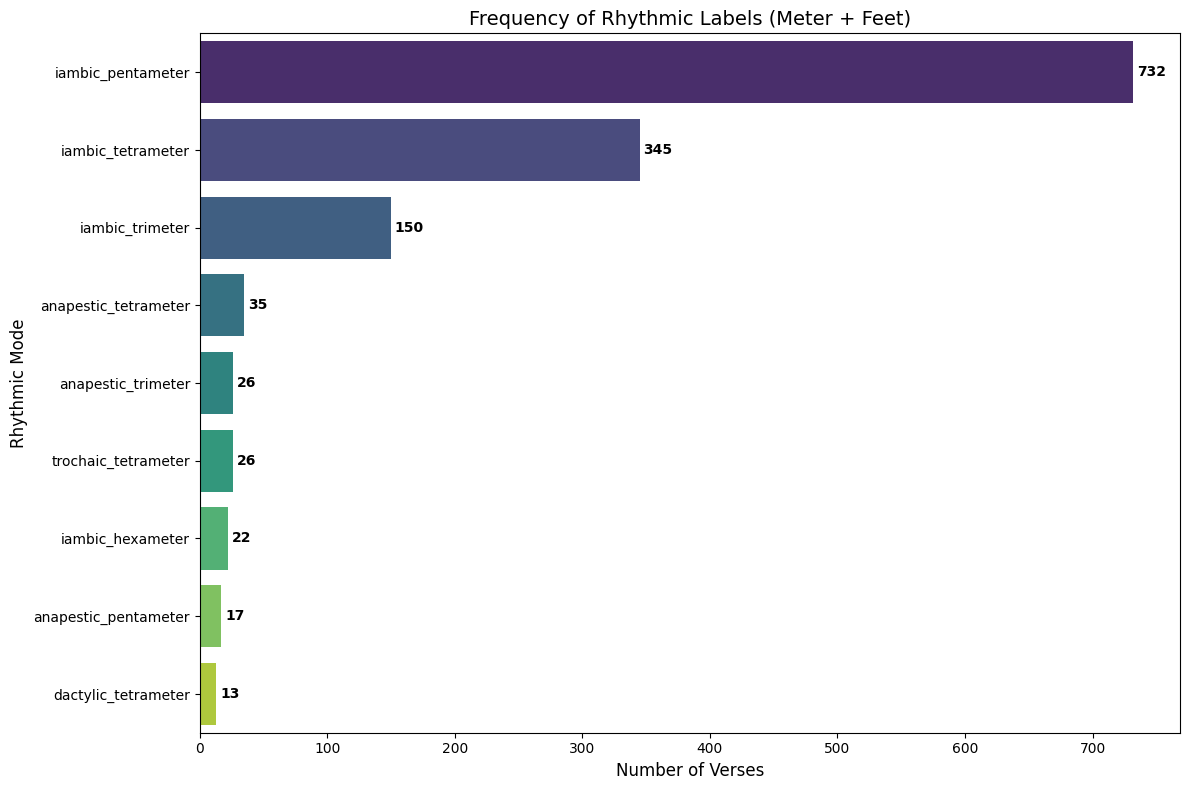

In [15]:
df["label_full"] = df["meter_quality"].str.lower() + "_" + df["feet_number"].str.lower()

# Calculate frequencies[cite: 1, 2]
counts = df["label_full"].value_counts()

# Set up the visualization
plt.figure(figsize=(12, 8))
sns.barplot(x=counts.values, y=counts.index, palette="viridis")

# Add chart details
plt.title("Frequency of Rhythmic Labels (Meter + Feet)", fontsize=14)
plt.xlabel("Number of Verses", fontsize=12)
plt.ylabel("Rhythmic Mode", fontsize=12)

# Annotate bars with the exact count
for i, v in enumerate(counts.values):
    plt.text(v + 3, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Feature extraction

In [9]:
def extract_features(seq):
    """
    Convertit une séquence en vecteur de features
    """
    return [
        sum(seq)/len(seq),  # proportion de syllabes accentuées
        len(seq),  # longueur du vers
        sum(seq[i]==0 and seq[i+1]==1 for i in range(len(seq)-1)),  # transitions 0→1
        sum(seq[i]==1 and seq[i+1]==0 for i in range(len(seq)-1)),  # transitions 1→0
    ]

In [10]:
X_features = df["sequence"].reset_index(drop=True).apply(extract_features).tolist()
scaler = MinMaxScaler() # feature scaling
X_features = scaler.fit_transform(np.array(X_features))

## 4. Data splitting

In [11]:
y = df["label_full"].apply(lambda x : label_to_id[x]).reset_index(drop=True)
X = df["sequence"].reset_index(drop=True)

In [12]:
data = []
for i in range(len(X)):
    data.append((X[i], X_features[i], y[i]))
len(data)

1366

In [13]:
# We use stratification because of the heterogeneity of our classes.
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, stratify=y)
y_temp = [label for _, _, label in temp_data]
dev_data, test_data = train_test_split(temp_data, test_size=0.50, random_state=42, stratify=y_temp)

In [14]:
test_data

[([0, 1, 0, 1, 0, 1, 0, 1],
  array([0.35897436, 0.27272727, 0.6       , 0.5       ]),
  1),
 ([0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
  array([0.23076923, 0.81818182, 1.        , 1.        ]),
  6),
 ([0, 1, 0, 0, 1, 0, 1, 0, 1],
  array([0.25925926, 0.36363636, 0.6       , 0.5       ]),
  3),
 ([1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1],
  array([0.23076923, 0.81818182, 0.6       , 0.66666667]),
  7),
 ([0, 0, 1, 0, 1, 0, 1],
  array([0.23076923, 0.18181818, 0.4       , 0.33333333]),
  2),
 ([1, 1, 0, 1, 1, 0, 0, 1, 1, 1],
  array([0.71794872, 0.45454545, 0.2       , 0.33333333]),
  0),
 ([0, 0, 1, 1, 1, 0, 0, 1, 0],
  array([0.25925926, 0.36363636, 0.2       , 0.33333333]),
  4),
 ([1, 0, 0, 1, 0, 1, 0, 1, 0, 1],
  array([0.35897436, 0.45454545, 0.6       , 0.66666667]),
  0),
 ([1, 0, 1, 0, 1, 1, 1],
  array([0.74358974, 0.18181818, 0.2       , 0.33333333]),
  1),
 ([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
  array([0.27738928, 0.54545455, 0.8       , 0.83333333]),
  0),
 ([1, 1, 1, 0

In [297]:
# this dataset will presently be used to compare models
results_dev = pd.DataFrame({"datapoint_id": range(len(dev_data)),"gold_standard": [label for _, _, label in dev_data]})

## 5. Models

### 5.1 Feature-based MLP



In [298]:
class MLP(nn.Module):
    def __init__(self, input_size, output_size, n_layers=2, hidden_size=32):
        super().__init__()
        # Define the shape of the network as a list of layer sizes
        dims = [input_size] + [hidden_size] * (n_layers - 1) + [output_size]
        # Make the linear layers with ReLU in between each internal layer
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)

In [299]:
def train_mlp(train_data, dev_data, n_epochs, lr=1e-3):
    model = MLP(input_size=4, output_size=9, hidden_size=32)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_loss = float("inf")
    best_state = None
    best_preds = None

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0

        for seq, features, label in train_data:

            x = torch.tensor(features, dtype=torch.float32).unsqueeze(0)
            y = torch.tensor([label], dtype=torch.long)

            logits = model(x)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_data)
        model.eval()
        y_true = []
        dev_preds = []
        dev_loss = 0

        with torch.no_grad():
            for seq, features, label in dev_data:
                x = torch.tensor(features, dtype=torch.float32).unsqueeze(0)
                y = torch.tensor([label], dtype=torch.long)
                logits = model(x)
                loss = criterion(logits, y)
                dev_loss += loss.item()
                pred = torch.argmax(logits, dim=1).item()
                y_true.append(label)
                dev_preds.append(pred)

        dev_loss /= len(dev_data)
        dev_f1 = f1_score(y_true, dev_preds, average="macro", zero_division=0)

        if epoch % 10 == 0:
            print(epoch, train_loss, dev_loss, dev_f1)
        if dev_loss < best_loss:
            best_loss = dev_loss
            best_state = copy.deepcopy(model.state_dict())
            best_preds = dev_preds.copy()

    model.load_state_dict(best_state)

    return model, best_preds

In [ ]:
mlp_model, mlp_preds = train_mlp(train_data, dev_data, 200)

0 1.331650947676543 1.1145409573142122 0.0871697798730907
10 0.46072471481221866 0.48177897110581397 0.30385192762126656
20 0.30944892276218744 0.3396389330487426 0.518240101133234
30 0.24732435981492915 0.28022105532312175 0.6110420979986197
40 0.21578355903430257 0.2533855473923656 0.7060130745229943


In [ ]:
results_dev["MLP"] = mlp_preds

### 5.2 Rule-based model

In [ ]:
def classify_rule_fixed(seq):
    classes = {
    'iambic_pentameter':     [0,1]*5,
    'iambic_tetrameter':     [0,1]*4,
    'iambic_trimeter':       [0,1]*3,

    'iambic_hexameter':      [0,1]*6,

    'trochaic_tetrameter':   [1,0]*4,

    'anapestic_trimeter':    [0,0,1]*3,
    'anapestic_tetrameter':  [0,0,1]*4,
    'anapestic_pentameter':  [0,0,1]*5,

    'dactylic_tetrameter':   [1,0,0]*4}

    best_score = -1
    best_label = None
    # Testing each type of metre
    for label, base_pattern in classes.items():

        # building a pattern whose length is equal to that of the sequence
        pattern = (base_pattern * (len(seq)//len(base_pattern)+2))[:len(seq)]

        #computing similarity
        score = sum(
            s == p for s, p in zip(seq, pattern)
        ) / len(seq)

        if score > best_score:
            best_score = score
            best_label = label

    return label_to_id[best_label]

In [ ]:
rule_based_preds = []
for seq, _, _ in dev_data:
    pred = classify_rule_fixed(seq)
    rule_based_preds.append(pred)
results_dev["rule_based"] = rule_based_preds

In [ ]:
results_dev

,datapoint_id,gold_standard,MLP,rule_based
0,0,0,0,8
1,1,0,0,0
2,2,1,1,5
3,3,1,1,0
4,4,1,1,0
...,...,...,...,...
200,200,0,0,0
201,201,0,0,0
202,202,0,0,0
203,203,0,0,5


In [ ]:

f1_rule = f1_score(results_dev["gold_standard"], results_dev["rule_based"], average="macro")

print(f1_rule)

0.15022015022015023


### 5.3 LSTMs

In [ ]:
class MeterLSTM(nn.Module):

    def __init__(self, input_size=1, hidden_size=64, num_layers=1, num_classes=9):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.lin = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        # x shape:
        # (batch_size, seq_len, 1)

        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]

        logits = self.lin(last_hidden)

        return logits

In [ ]:
def trainlstm(train_data, dev_data, n_epochs, learning_rate=1e-3):

    model = MeterLSTM(hidden_size=64)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    best_loss = float("inf")
    best_state = None
    best_dev_preds = None

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0

        for seq, _, label in train_data:

            x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
            y = torch.tensor([label], dtype=torch.long)

            logits = model(x)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_data)

        model.eval()
        y_true = []
        dev_preds = []
        dev_loss = 0
        with torch.no_grad():
            for seq, _, label in dev_data:
                x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
                y = torch.tensor([label], dtype=torch.long)
                logits = model(x)
                loss = criterion(logits, y)
                dev_loss += loss.item()
                pred = torch.argmax(logits, dim=1).item()
                y_true.append(label)
                dev_preds.append(pred)

        dev_loss /= len(dev_data)

        dev_f1 = f1_score(y_true, dev_preds, average="macro", zero_division=0)
        if epoch % 10 == 0:
            print("Epoch:", epoch)
            print("Train loss:", epoch_loss)
            print("Dev loss:", dev_loss)
            print("Dev F1:", dev_f1)

        if dev_loss < best_loss:
            best_loss = dev_loss
            best_state = copy.deepcopy(model.state_dict())
            best_dev_preds = dev_preds.copy()

    model.load_state_dict(best_state)

    return model, best_dev_preds

In [ ]:
lstm_model, lstm_preds = trainlstm(train_data, dev_data, 100)

Epoch: 0
Train loss: 1.031634757770654
Dev loss: 0.7656921039449005
Dev F1: 0.2821746690798112
Epoch: 10
Train loss: 0.3676949024753778
Dev loss: 0.34902258541253284
Dev F1: 0.5037588285074026
Epoch: 20
Train loss: 0.2646530614194078
Dev loss: 0.3201738992189171
Dev F1: 0.6332169331717762
Epoch: 30
Train loss: 0.16996200164978756
Dev loss: 0.3091588130523167
Dev F1: 0.6607252391169726
Epoch: 40
Train loss: 0.1060162665088679
Dev loss: 0.3411573073045186
Dev F1: 0.6486975966626379
Epoch: 50
Train loss: 0.08827743444881389
Dev loss: 0.3212559600454835
Dev F1: 0.6898188231521566
Epoch: 60
Train loss: 0.07348092874073717
Dev loss: 0.35339582398301433
Dev F1: 0.6994944046723982
Epoch: 70
Train loss: 0.06739717880567188
Dev loss: 0.3252993282405508
Dev F1: 0.7653986318692201
Epoch: 80
Train loss: 0.06660499568460254
Dev loss: 0.288974563441577
Dev F1: 0.7641126166240322
Epoch: 90
Train loss: 0.06898193695631023
Dev loss: 0.3083778657839835
Dev F1: 0.7989937757879886


In [ ]:
results_dev["LSTM"] = lstm_preds

In [ ]:
results_dev

,datapoint_id,gold_standard,MLP,rule_based,LSTM
0,0,0,0,8,0
1,1,0,0,0,0
2,2,1,1,5,1
3,3,1,1,0,1
4,4,1,1,0,1
...,...,...,...,...,...
200,200,0,0,0,0
201,201,0,0,0,0
202,202,0,0,0,0
203,203,0,0,5,0


In [ ]:
def evaluate(model, data):
  model.eval()
  y_true = []
  y_pred = []
  total_loss = 0
  criterion = nn.CrossEntropyLoss()
  with torch.no_grad():

      for seq, _, label in data:
          x = torch.tensor(seq, dtype=torch.float32)
          x = x.unsqueeze(0).unsqueeze(-1)
          y = torch.tensor([label], dtype=torch.long)

          logits = model(x)
          loss = criterion(logits, y)
          total_loss += loss.item()

          pred = torch.argmax(logits, dim=1).item()
          y_true.append(label)
          y_pred.append(pred)

  f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
  mean_loss = total_loss / len(data)

  return "F1 : ", f1, "mean loss : ", mean_loss

### 5.4 Linear classifier using features + LSTM's last hidden representations

In [ ]:
#The idea is to combine the feature model with the LSTM by taking the results of the LSTM (the hidden last representations) and putting them into an MLP with the previous features.
class MeterLSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, num_global_features=4, num_classes=9):

        super().__init__()

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)

        self.lin = nn.Linear(hidden_size + num_global_features, num_classes)

    def forward(self, seq, global_features):

        # seq shape:
        # (batch, seq_len, 1)

        out, (h_n, c_n) = self.lstm(seq)
        last_hidden = h_n[-1]

        # concaténation
        combined = torch.cat([last_hidden, global_features], dim=1)

        logits = self.lin(combined)

        return logits

In [ ]:
def trainLstmClassifier(train_data, dev_data, n_epochs, learning_rate=1e-3) :
  model = MeterLSTMClassifier()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
  criterion = nn.CrossEntropyLoss()

  best_loss = float("inf")
  best_state = None
  best_dev_preds = None
  for epoch in range(n_epochs):
      epoch_loss = 0
      model.train()
      for seq, features, label in train_data:
          x_seq = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
          x_features= torch.tensor([features], dtype=torch.float32)
          y = torch.tensor([label], dtype=torch.long)

          logits = model(x_seq, x_features)
          loss = criterion(logits, y)
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()
          epoch_loss += loss.item()
      epoch_loss /= len(train_data)
      model.eval()
      y_true = []
      dev_preds = []
      dev_loss = 0
      with torch.no_grad():
              for seq, features, label in dev_data:
                  x_seq = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
                  x_features= torch.tensor([features], dtype=torch.float32)
                  y = torch.tensor([label])
                  logits = model(x_seq, x_features)
                  loss = criterion(logits, y)
                  dev_loss += loss.item()
                  pred = torch.argmax(logits, dim=1).item()
                  y_true.append(label)
                  dev_preds.append(pred)
      dev_f1 = f1_score(y_true, dev_preds, average="macro", zero_division=0)
      dev_loss = dev_loss / len(dev_data)
      if epoch % 10 == 0:
            print("Epoch:", epoch)
            print("Train loss:", epoch_loss)
            print("Dev loss:", dev_loss)
            print("Dev F1:", dev_f1)
      if dev_loss < best_loss:
            best_loss = dev_loss
            best_state = copy.deepcopy(model.state_dict())
            best_dev_preds = dev_preds.copy()
  model.load_state_dict(best_state)
  return model, best_dev_preds

In [ ]:
def evaluate2(model, data):
  model.eval()
  y_true = []
  y_pred = []
  total_loss = 0
  criterion = nn.CrossEntropyLoss()
  with torch.no_grad():
      for seq, features, label in data:
          x_seq = torch.tensor(seq, dtype=torch.float32)
          x_seq = x_seq.unsqueeze(0).unsqueeze(-1)
          x_features= torch.tensor([features], dtype=torch.float32)
          y = torch.tensor([label], dtype=torch.long)

          logits = model(x_seq, x_features)
          loss = criterion(logits, y)
          total_loss += loss.item()

          pred = torch.argmax(logits, dim=1).item()
          y_true.append(label)
          y_pred.append(pred)
  f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
  mean_loss = total_loss / len(data)
  return "F1 : ", f1, "mean loss : ", mean_loss

###

In [ ]:
hybrid_model, hybrid_preds = trainLstmClassifier(
    train_data,
    dev_data,
    100
)

Epoch: 0
Train loss: 1.1464147129832576
Dev loss: 0.8678193792700768
Dev F1: 0.17640513076794936
Epoch: 10
Train loss: 0.36891542247469267
Dev loss: 0.40192668305755386
Dev F1: 0.4551737216935455
Epoch: 20
Train loss: 0.26844946445339984
Dev loss: 0.2990301226833608
Dev F1: 0.6272704025064145
Epoch: 30
Train loss: 0.23958819913853224
Dev loss: 0.2996619686427549
Dev F1: 0.6573761601835435
Epoch: 40
Train loss: 0.19140450290211128
Dev loss: 0.25778833183760913
Dev F1: 0.7117091502492598
Epoch: 50
Train loss: 0.1537329019571402
Dev loss: 0.2556422884584541
Dev F1: 0.7205292176168073
Epoch: 60
Train loss: 0.12412859147307283
Dev loss: 0.22860513062517318
Dev F1: 0.7957762739946106
Epoch: 70
Train loss: 0.08865132658734011
Dev loss: 0.26950839294039747
Dev F1: 0.7053135327932794
Epoch: 80
Train loss: 0.07600435602037132
Dev loss: 0.22364910408157412
Dev F1: 0.7779709776973799
Epoch: 90
Train loss: 0.0708499406465844
Dev loss: 0.25118312384600844
Dev F1: 0.7261178887818025


In [ ]:
results_dev["LSTM_classifier"] = hybrid_preds

## 6. Model comparison (permutation tests)

In [ ]:
def permutation_test(model_1, model_2, n_perm=1000):
    y_true = results_dev["gold_standard"].values
    m1 = results_dev[model_1].values
    m2 = results_dev[model_2].values
    obs_diff = abs(f1_score(y_true, m1, average="macro") - f1_score(y_true, m2, average="macro"))

    count = 0
    for _ in range(n_perm):
        m1_perm = []
        m2_perm = []
        for i in range(len(results_dev)):
            if random.random() < 0.5:
                m1_perm.append(m1[i])
                m2_perm.append(m2[i])
            else:
                m1_perm.append(m2[i])
                m2_perm.append(m1[i])

        perm_diff = abs(f1_score(y_true, m1_perm, average="macro") - f1_score(y_true, m2_perm, average="macro"))

        if perm_diff >= obs_diff:
            count += 1

    p_value = (count + 1) / (n_perm + 1)
    return obs_diff, p_value

In [ ]:
res1 = permutation_test("rule_based", "LSTM")
print(res1)

(0.6172503285852734, 0.000999000999000999)


In [ ]:
labels_train  = [i for _ ,_ ,i in train_data]
majority_class = Counter(labels_train).most_common(1)[0][0]
majority_class

0

In [ ]:
results_dev["majority_baseline"] = majority_class * len(results_dev)

In [ ]:
for model in ['majority_baseline', 'rule_based','LSTM', 'LSTM_classifier', 'MLP']:
  print(f"F1 ({model}) : ", f1_score(results_dev["gold_standard"], results_dev[model], average="macro"))

F1 (majority_baseline) :  0.07760141093474426
F1 (rule_based) :  0.15022015022015023
F1 (LSTM) :  0.7674704788054236
F1 (LSTM_classifier) :  0.781451585288439
F1 (MLP) :  0.7401522920620848


In [ ]:
pairs = [("rule_based", "majority_baseline"), ("MLP", "majority_baseline"), ("LSTM_classifier", "MLP"), ("LSTM_classifier", "LSTM"), ("LSTM_classifier", "rule_based"), ("LSTM", "rule_based"),("LSTM", "MLP")]

In [ ]:

for pair in pairs:
  _, p = permutation_test(pair[0], pair[1])
  print(f"{pair[0]} better than {pair[1]} : p_bonferroni = ", min(p * len(pairs), 1.0))

rule_based better than majority_baseline : p_bonferroni =  1.0
MLP better than majority_baseline : p_bonferroni =  0.006993006993006993
LSTM_classifier better than MLP : p_bonferroni =  1.0
LSTM_classifier better than LSTM : p_bonferroni =  1.0
LSTM_classifier better than rule_based : p_bonferroni =  0.006993006993006993
LSTM better than rule_based : p_bonferroni =  0.006993006993006993
LSTM better than MLP : p_bonferroni =  1.0


In [ ]:
for model in [
    'majority_baseline',
    'rule_based',
    'MLP',
    'LSTM',
    'LSTM_classifier'
]:
    print(
        model,
        f1_score(
            results_dev["gold_standard"],
            results_dev[model],
            average="macro"
        )
    )

majority_baseline 0.07760141093474426
rule_based 0.15022015022015023
MLP 0.7401522920620848
LSTM 0.7674704788054236
LSTM_classifier 0.781451585288439


## 7. Final evaluation on test set

In [ ]:
y_test = [label for _, _, label in test_data]

majority_preds_test = [majority_class] * len(test_data)

print("Majority baseline")
print("F1 =", f1_score(y_test, majority_preds_test, average="macro"))
print()

Majority baseline
F1 = 0.07760141093474426



In [ ]:
rule_based_preds_test = []

for seq, _, _ in test_data:
    pred = classify_rule_fixed(seq)
    rule_based_preds_test.append(pred)

print("Rule-based model")
print("F1 =", f1_score(y_test, rule_based_preds_test, average="macro"))
print()

Rule-based model
F1 = 0.12602733248214876



In [ ]:
mlp_model.eval()

mlp_preds_test = []

with torch.no_grad():

    for seq, features, label in test_data:

        x = torch.tensor(features, dtype=torch.float32).unsqueeze(0)

        logits = mlp_model(x)

        pred = torch.argmax(logits, dim=1).item()

        mlp_preds_test.append(pred)

print("MLP")
print("F1 =", f1_score(y_test, mlp_preds_test, average="macro"))
print()

MLP
F1 = 0.7456969098478532



In [ ]:
lstm_model.eval()

lstm_preds_test = []

with torch.no_grad():

    for seq, _, label in test_data:

        x = torch.tensor(seq, dtype=torch.float32)
        x = x.unsqueeze(0).unsqueeze(-1)

        logits = lstm_model(x)

        pred = torch.argmax(logits, dim=1).item()

        lstm_preds_test.append(pred)

print("LSTM")
print("F1 =", f1_score(y_test, lstm_preds_test, average="macro"))
print()

LSTM
F1 = 0.7043870965439593



In [ ]:
hybrid_model.eval()

hybrid_preds_test = []

with torch.no_grad():

    for seq, features, label in test_data:

        x_seq = torch.tensor(seq, dtype=torch.float32)
        x_seq = x_seq.unsqueeze(0).unsqueeze(-1)

        x_features = torch.tensor(
            [features],
            dtype=torch.float32
        )

        logits = hybrid_model(
            x_seq,
            x_features
        )

        pred = torch.argmax(
            logits,
            dim=1
        ).item()

        hybrid_preds_test.append(pred)

print("Hybrid")
print("F1 =", f1_score(
    y_test,
    hybrid_preds_test,
    average="macro"
))

Hybrid
F1 = 0.6855236676337594


In [ ]:
results_test = pd.DataFrame({

    "Model": [
        "Majority baseline",
        "Rule-based",
        "MLP",
        "LSTM",
        "Hybrid"
    ],

    "Macro F1": [

        f1_score(
            y_test,
            majority_preds_test,
            average="macro"
        ),

        f1_score(
            y_test,
            rule_based_preds_test,
            average="macro"
        ),

        f1_score(
            y_test,
            mlp_preds_test,
            average="macro"
        ),

        f1_score(
            y_test,
            lstm_preds_test,
            average="macro"
        ),

        f1_score(
            y_test,
            hybrid_preds_test,
            average="macro"
        )
    ]
})

results_test.sort_values(
    by="Macro F1",
    ascending=False
)

,Model,Macro F1
2,MLP,0.745697
3,LSTM,0.704387
4,Hybrid,0.685524
1,Rule-based,0.126027
0,Majority baseline,0.077601


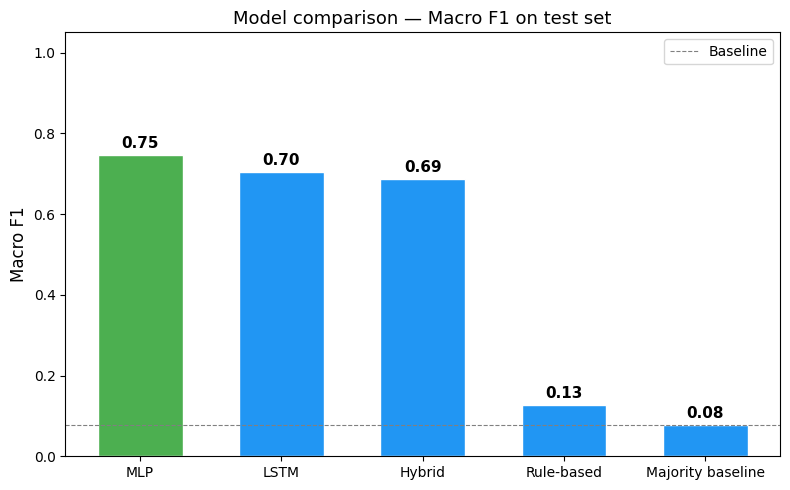

In [ ]:
results_sorted = results_test.sort_values(by="Macro F1", ascending=False)

colors = ["#2196F3" if model != results_sorted.iloc[0]["Model"] else "#4CAF50" 
          for model in results_sorted["Model"]]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(results_sorted["Model"], results_sorted["Macro F1"], color=colors, edgecolor="white", width=0.6)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
            f"{height:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0, 1.05)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("Model comparison — Macro F1 on test set", fontsize=13)
ax.axhline(y=results_sorted.iloc[-1]["Macro F1"], color="gray", linestyle="--", linewidth=0.8, label="Baseline")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
results_test = pd.DataFrame({
    "gold_standard": y_test,
    "majority_baseline": majority_preds_test,
    "rule_based": rule_based_preds_test,
    "MLP": mlp_preds_test,
    "LSTM": lstm_preds_test,
    "LSTM_classifier": hybrid_preds_test
})

In [ ]:
def permutation_test_test(model_1, model_2, n_perm=1000):

    y_true = results_test["gold_standard"].values

    m1 = results_test[model_1].values
    m2 = results_test[model_2].values

    observed_diff = abs(
        f1_score(y_true, m1, average="macro")
        -
        f1_score(y_true, m2, average="macro")
    )

    count = 0

    for _ in range(n_perm):

        m1_perm = []
        m2_perm = []

        for i in range(len(y_true)):

            if random.random() < 0.5:

                m1_perm.append(m1[i])
                m2_perm.append(m2[i])

            else:

                m1_perm.append(m2[i])
                m2_perm.append(m1[i])

        perm_diff = abs(
            f1_score(y_true, m1_perm, average="macro")
            -
            f1_score(y_true, m2_perm, average="macro")
        )

        if perm_diff >= observed_diff:
            count += 1

    p_value = (count + 1) / (n_perm + 1)

    return observed_diff, p_value

In [ ]:
pairs = [

    ("LSTM_classifier", "LSTM"),

    ("LSTM_classifier", "MLP"),

    ("LSTM", "MLP"),

    ("LSTM_classifier", "rule_based"),

    ("LSTM", "rule_based"),

    ("MLP", "rule_based")
]

In [ ]:
for pair in pairs:

    diff, p = permutation_test_test(
        pair[0],
        pair[1]
    )

    p_bonferroni = min(
        p * len(pairs),
        1.0
    )

    print(
        f"{pair[0]} vs {pair[1]}"
    )

    print(
        f"Difference in F1 = {diff:.4f}"
    )

    print(
        f"p-value (Bonferroni) = {p_bonferroni:.4f}"
    )

    print()

LSTM_classifier vs LSTM
Difference in F1 = 0.0189
p-value (Bonferroni) = 1.0000

LSTM_classifier vs MLP
Difference in F1 = 0.0602
p-value (Bonferroni) = 1.0000

LSTM vs MLP
Difference in F1 = 0.0413
p-value (Bonferroni) = 1.0000

LSTM_classifier vs rule_based
Difference in F1 = 0.5595
p-value (Bonferroni) = 0.0060

LSTM vs rule_based
Difference in F1 = 0.5784
p-value (Bonferroni) = 0.0060

MLP vs rule_based
Difference in F1 = 0.6197
p-value (Bonferroni) = 0.0060



In [ ]:
id_to_label = {v:k for k,v in label_to_id.items()}

labels = [id_to_label[i] for i in range(len(id_to_label))]

In [ ]:
print(
    classification_report(
        y_test,
        mlp_preds_test,
        target_names=labels,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

   iambic_pentameter       0.97      0.99      0.98       110
   iambic_tetrameter       0.89      0.96      0.92        51
     iambic_trimeter       1.00      1.00      1.00        23
anapestic_tetrameter       1.00      0.40      0.57         5
  anapestic_trimeter       1.00      1.00      1.00         4
 trochaic_tetrameter       0.50      0.25      0.33         4
    iambic_hexameter       1.00      1.00      1.00         3
anapestic_pentameter       0.50      0.33      0.40         3
 dactylic_tetrameter       0.50      0.50      0.50         2

            accuracy                           0.94       205
           macro avg       0.82      0.72      0.75       205
        weighted avg       0.94      0.94      0.93       205



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    mlp_preds_test
)

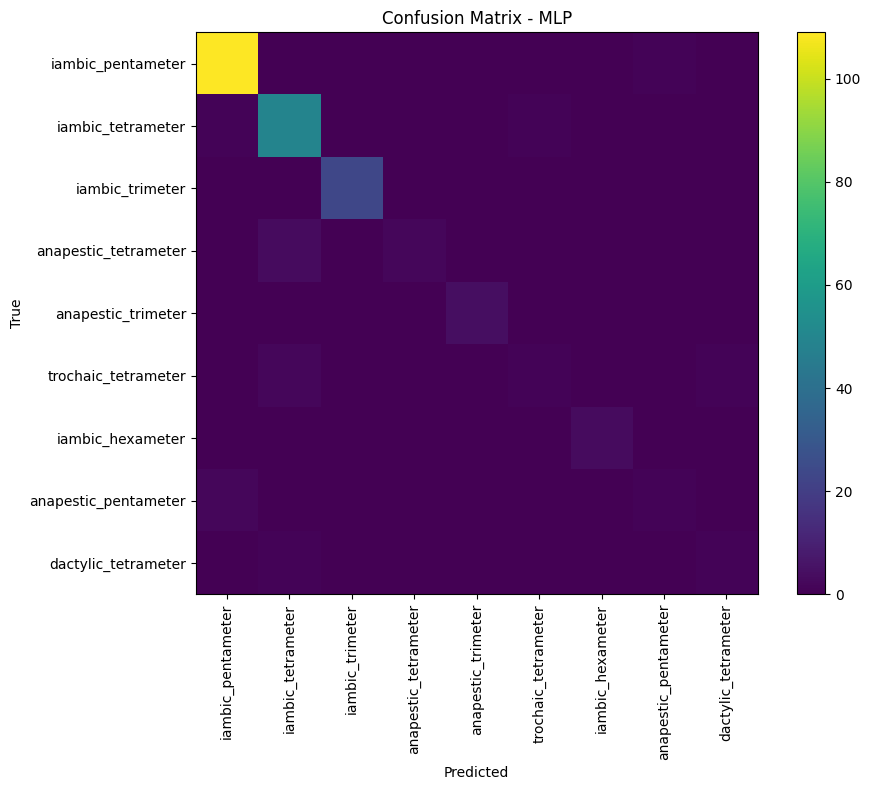

In [ ]:
plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.xticks(
    range(len(labels)),
    labels,
    rotation=90
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix - MLP")

plt.tight_layout()

plt.show()

In [ ]:
test_data

[([0, 1, 0, 1, 0, 1, 0, 1],
  array([0.35897436, 0.27272727, 0.6       , 0.5       ]),
  1),
 ([0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
  array([0.23076923, 0.81818182, 1.        , 1.        ]),
  6),
 ([0, 1, 0, 0, 1, 0, 1, 0, 1],
  array([0.25925926, 0.36363636, 0.6       , 0.5       ]),
  3),
 ([1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1],
  array([0.23076923, 0.81818182, 0.6       , 0.66666667]),
  7),
 ([0, 0, 1, 0, 1, 0, 1],
  array([0.23076923, 0.18181818, 0.4       , 0.33333333]),
  2),
 ([1, 1, 0, 1, 1, 0, 0, 1, 1, 1],
  array([0.71794872, 0.45454545, 0.2       , 0.33333333]),
  0),
 ([0, 0, 1, 1, 1, 0, 0, 1, 0],
  array([0.25925926, 0.36363636, 0.2       , 0.33333333]),
  4),
 ([1, 0, 0, 1, 0, 1, 0, 1, 0, 1],
  array([0.35897436, 0.45454545, 0.6       , 0.66666667]),
  0),
 ([1, 0, 1, 0, 1, 1, 1],
  array([0.74358974, 0.18181818, 0.2       , 0.33333333]),
  1),
 ([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
  array([0.27738928, 0.54545455, 0.8       , 0.83333333]),
  0),
 ([1, 1, 1, 0